In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print(f"numpy {np.__version__}")
print(f"scipy {scipy.__version__}")
print(f"pandas {pd.__version__}")

# Phase 1 Week 1 preview — Black-Scholes call
def bsm_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*stats.norm.cdf(d1) - K*np.exp(-r*T)*stats.norm.cdf(d2)

price = bsm_call(S=100, K=100, T=1.0, r=0.05, sigma=0.2)
print(f"ATM 1Y call, σ=20%, r=5%: {price:.4f}")

numpy 2.4.6
scipy 1.17.1
pandas 3.0.3
ATM 1Y call, σ=20%, r=5%: 10.4506


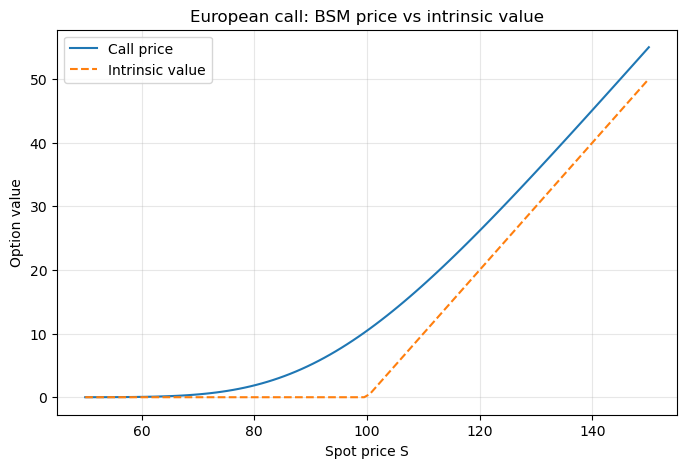

In [2]:
S = np.linspace(50, 150, 100)
prices = [bsm_call(s, 100, 1.0, 0.05, 0.2) for s in S]
payoffs = np.maximum(S - 100, 0)

plt.figure(figsize=(8, 5))
plt.plot(S, prices, label='Call price')
plt.plot(S, payoffs, '--', label='Intrinsic value')
plt.xlabel('Spot price S')
plt.ylabel('Option value')
plt.title('European call: BSM price vs intrinsic value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()